# Network activity

[The previous notebook](./2.1%20Anatomical%20embedding.ipynb) provided us with an anatomical reconstruction of the barrel cortex, defining locations of presynaptic cells, and post-synaptic targets onto our cell. Given this anatomical data, we can now activate the synapses according to experimental data.

To do this, we need the following information
 1. A parameter file specifying characteristics of the synaspses by celltype
 2. A parameterfile specifying the ongoing activity by celltype
 3. Parameterfiles specifying evoked response by stimulus, celltype and cell location

In [1]:
from pathlib import Path
tutorial_output_dir = f"{Path.home()}/isf_tutorial_output"  # <-- Change this to your desired output directory

In [2]:
import Interface as I
from getting_started import getting_started_dir
%matplotlib inline

[INFO] ISF: Current version: heads/scim+0.ga9c9e61ce.dirty
[INFO] ISF: Current pid: 4188502
[INFO] l5pt: Loaded mechanisms in NEURON namespace.


--No graphics will be displayed.


[ATTENTION] ISF: The source folder has uncommited changes!



[INFO] ISF: Loaded modules with __version__ attribute are:
IPython: 8.18.1, Interface: heads/scim+0.ga9c9e61ce.dirty, PIL: 11.3.0, _brotli: 1.1.0, _csv: 1.0, _ctypes: 1.1.0, _curses: b'2.2', _decimal: 1.70, argparse: 1.1, blosc: 1.11.3, bluepyopt: 1.9.126, brotli: 1.1.0, certifi: 2025.08.03, charset_normalizer: 3.4.3, click: 7.1.2, cloudpickle: 3.1.1, colorama: 0.4.6, comm: 0.2.3, csv: 1.0, ctypes: 1.1.0, cycler: 0.12.1, cytoolz: 1.0.1, dash: 2.18.2, dask: 2.30.0, dateutil: 2.9.0.post0, deap: 1.4, debugpy: 1.8.16, decimal: 1.70, decorator: 5.2.1, defusedxml: 0.7.1, distributed: 2.30.0, distutils: 3.9.23, entrypoints: 0.4, exceptiongroup: 1.3.0, executing: 2.2.0, fasteners: 0.17.3, flask: 1.1.4, fsspec: 2025.7.0, future: 1.0.0, greenlet: 3.2.4, idna: 3.10, ipaddress: 1.0, ipykernel: 6.29.5, ipywidgets: 8.1.7, isf_pandas_msgpack: 0.4.0, itsdangerous: 1.1.0, jedi: 0.19.2, jinja2: 2.11.3, joblib: 1.5.1, json: 2.0.9, jupyter_clie

In [3]:
I.logger.setLevel("INFO")

## Exploring the data

Running simulations with network activity in ISF requires you to know which kind of network activity you would want to simulate.

In the next section, we show how you can build [network parameters](https://mpinb.github.io/in_silico_framework/file_formats#network-parameters), containing cell type-specific information on the following:
- The network embedding (see the [previous tutorial](./2.1%20Anatomical%20embedding.ipynb))
- Synapse dynamics
- Network activity (ongoing and/or evoked)

Before we do that, we will first explore exactly what this data is, and how it should look like for use in ISF

### Activity data

Activity data in ISF can be defined in many ways, from distributions (normal, lognormal, uniform), to empirically measured PSTHs.

In this tutorial, we will consider activity data capturing the empirically measured network activity during a specific *in vivo* condition.

The experimental condition we will consider here is a passive whisker touch of the rat.
We have files capturing the activity of all celltypes in all locations across the rat barrel cortex.
Let's see what these files look like:

In [4]:
evoked_activity_dir = Path(getting_started_dir) / "example_data" / "functional_constraints" / "evoked_activity"
evoked_activity_files = list(evoked_activity_dir.glob("*.param"))
[str(paramfile.name) for paramfile in evoked_activity_files]

['Beta_stim.param',
 'D4_stim.param',
 'E2_stim.param',
 'D3_stim.param',
 'C4_stim.param',
 'B2_stim.param',
 'C2_stim.param',
 'A1_stim.param',
 'A3_stim.param',
 'C1_stim.param',
 'A4_stim.param',
 'E3_stim.param',
 'B4_stim.param',
 'E1_stim.param',
 'C3_stim.param',
 'Delta_stim.param',
 'B3_stim.param',
 'D2_stim.param',
 'Gamma_stim.param',
 'Alpha_stim.param',
 'B1_stim.param',
 'A2_stim.param',
 'D1_stim.param',
 'E4_stim.param']

Let's check what's inside these data files

In [5]:
I.scp.build_parameters(evoked_activity_files[0]).as_dict()

{'L2_B1': {'distribution': 'PSTH',
  'intervals': [[3.0, 4.0],
   [6.0, 7.0],
   [15.0, 16.0],
   [37.0, 38.0],
   [40.0, 41.0],
   [45.0, 46.0],
   [46.0, 47.0]],
  'probabilities': [0.0013, 0.0013, 0.0013, 0.0013, 0.0013, 0.0013, 0.0013]},
 'L2_C1': {'distribution': 'PSTH',
  'intervals': [[6.0, 7.0],
   [11.0, 12.0],
   [19.0, 20.0],
   [21.0, 22.0],
   [25.0, 26.0]],
  'probabilities': [0.0029, 0.0029, 0.0013, 0.0013, 0.0013]},
 'L2_Alpha': {'distribution': 'PSTH',
  'intervals': [[11.0, 12.0],
   [12.0, 13.0],
   [13.0, 14.0],
   [17.0, 18.0],
   [19.0, 20.0],
   [33.0, 34.0],
   [38.0, 39.0],
   [42.0, 43.0],
   [45.0, 46.0],
   [49.0, 50.0]],
  'probabilities': [0.0013,
   0.0013,
   0.0013,
   0.0013,
   0.0013,
   0.0029,
   0.0013,
   0.0029,
   0.0029,
   0.0013]},
 'L2_Beta': {'distribution': 'PSTH',
  'intervals': [[1.0, 2.0],
   [4.0, 5.0],
   [5.0, 6.0],
   [10.0, 11.0],
   [14.0, 15.0],
   [16.0, 17.0],
   [18.0, 19.0],
   [42.0, 43.0],
   [43.0, 44.0],
   [48.0, 49.0]]

These files are [Activity data files](https://mpinb.github.io/in_silico_framework/file_formats.html#activity-data). They define empirically measured Post-Synaptic Time Histograms (PSTHs) of various cell types!

Let's see what these PSTHs actually look like:

In [6]:
stimulated_whisker = "C2"
cell_type = "L6cc"
evoked_activity = I.scp.build_parameters(evoked_activity_dir / f"{stimulated_whisker}_stim.param")
L6cc_activity = {
    ct: evoked_activity[ct] 
    for ct in evoked_activity.keys() 
    if ct.startswith(cell_type)}

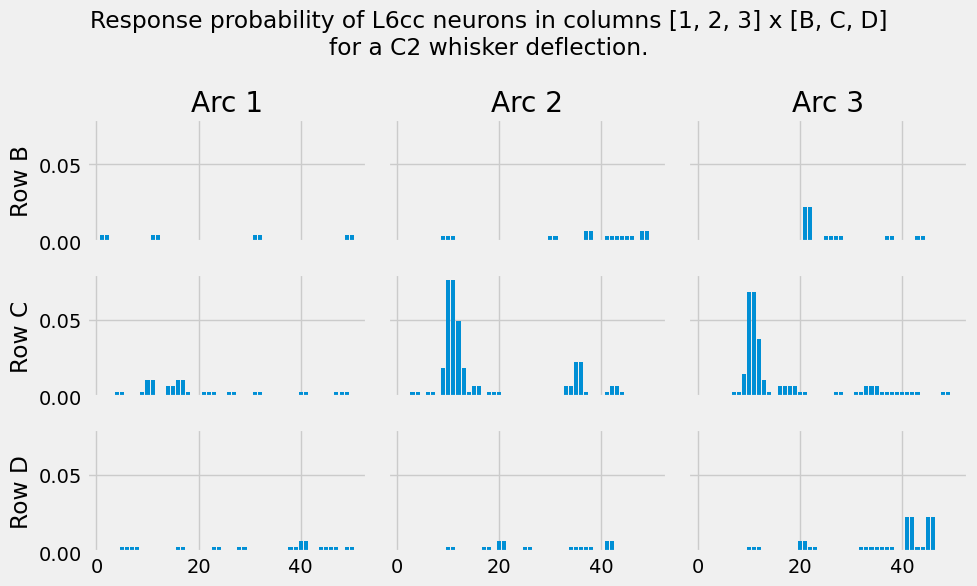

In [7]:
I.plt.style.use("fivethirtyeight")
arcs, rows = (1, 2, 3), ("B", "C", "D")
fig, axs = I.plt.subplots(
    len(rows), len(arcs), 
    sharey=True, 
    sharex=True, 
    figsize=(10, 6)
)

for celltype_stimwhisker, psth in L6cc_activity.items():
    p, bins = psth['probabilities'], psth['intervals']
    stimwhisker = celltype_stimwhisker.split('_')[-1]
    row, arc = stimwhisker  # unpack 2-character string
    ax_row_ind, ax_col_ind = rows.index(row), arcs.index(int(arc))
    for b, p_ in zip(bins, p):
        axs[ax_row_ind, ax_col_ind].bar(b, p_, color="C0")
    if ax_col_ind == 0: axs[ax_row_ind, ax_col_ind].set_ylabel("Row {}".format(rows[ax_row_ind]))
    if ax_row_ind == 0: axs[ax_row_ind, ax_col_ind].set_title("Arc {}".format(arcs[ax_col_ind]))

I.plt.suptitle(f"Response probability of {cell_type} neurons in columns [1, 2, 3] x [B, C, D]\nfor a C2 whisker deflection.")
fig.tight_layout()
I.plt.show()

### Ongoing activity

Ongoing activity is activity that does not depend on any kind of stimulus. ISF treats this as a special kind of activity source, modeled as Poisson spike trains. 

In [8]:
ongoing_data_dir = Path(getting_started_dir) / 'example_data' / 'functional_constraints' / 'ongoing_activity'

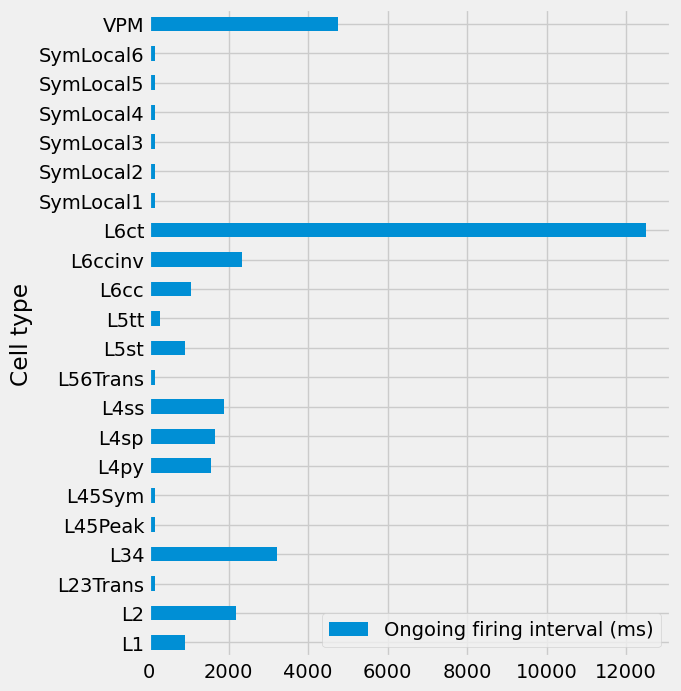

In [9]:
I.plt.style.use("fivethirtyeight")
ongoing_rates = I.pd.read_csv(ongoing_data_dir / "measured_ongoing_rates.csv", sep='\t')
ongoing_rates.set_index("Cell type").plot.barh(figsize=(6, 8));

We can see that ongoing activity is defined in terms of average interval (in $ms$) for each cell type.

Important for later: there is no distinction between where these cells are located. Ongoing activity is expected to be the same across cells of the same cell type, independent of where they are located.

### Synapse dynamics

We provide some default synapse dynamics models for glutamate and GABA receptors.

In [10]:
exc_syn_fn = Path(getting_started_dir) / "example_data" / "functional_constraints" / "exc_synapse_template.param"
I.scp.build_parameters(exc_syn_fn).as_dict()

{'synapses': {'receptors': {'glutamate_syn': {'threshold': 0.0,
    'delay': 0.0,
    'parameter': {'tau1': 26.0,
     'tau2': 2.0,
     'tau3': 2.0,
     'tau4': 0.1,
     'decayampa': 1.0,
     'decaynmda': 1.0},
    'weight': [1.0, 1.0]}},
  'releaseProb': 0.6}}

## Adding activity data to network parameters

[Network parameter files](https://mpinb.github.io/in_silico_framework/file_formats#network-parameters) contain cell type-specific information on the following:
- The network embedding (see the [previous tutorial](./2.1%20Anatomical%20embedding.ipynb))
- Synapse dynamics
- Network activity (ongoing and/or evoked)


Here, we use [`NetworkParameterBuilder`](../../../singlecell_input_mapper/network_param_builder.py) to add each component to a single cohesive parameter file. You could do this in a single line of code, but we will instead add each component one by one to inspect and explain the intermediate results.


The initial parameter object is empty, except for some auto-inferred info

In [11]:
from singlecell_input_mapper.network_param_builder import NetworkParamBuilder

new_netp = NetworkParamBuilder().network_parameters
new_netp.as_dict()

{'info': {'date': '2026-03-19', 'name': 'meulemeester'},
 'network': {},
 'NMODL_mechanisms': {}}

### Adding ongoing activity

In [12]:
celltype_to_ongoing_map = dict(
    zip(ongoing_rates['Cell type'], ongoing_rates['Ongoing firing interval (ms)'])
)

new_netp = NetworkParamBuilder(new_netp).add_ongoing_activity(
    # Mapping between cell type and ongoing interval in ms
    ongoing_interval_per_ct = celltype_to_ongoing_map

).network_parameters

new_netp.as_dict()

{'info': {'date': '2026-03-19', 'name': 'meulemeester'},
 'network': {'L1': {'celltype': {'spiketrain': {'interval': 909.1}}},
  'L2': {'celltype': {'spiketrain': {'interval': 2173.9}}},
  'L23Trans': {'celltype': {'spiketrain': {'interval': 142.9}}},
  'L34': {'celltype': {'spiketrain': {'interval': 3225.8}}},
  'L45Peak': {'celltype': {'spiketrain': {'interval': 142.9}}},
  'L45Sym': {'celltype': {'spiketrain': {'interval': 142.9}}},
  'L4py': {'celltype': {'spiketrain': {'interval': 1562.5}}},
  'L4sp': {'celltype': {'spiketrain': {'interval': 1666.7}}},
  'L4ss': {'celltype': {'spiketrain': {'interval': 1886.8}}},
  'L56Trans': {'celltype': {'spiketrain': {'interval': 142.9}}},
  'L5st': {'celltype': {'spiketrain': {'interval': 909.1}}},
  'L5tt': {'celltype': {'spiketrain': {'interval': 283.3}}},
  'L6cc': {'celltype': {'spiketrain': {'interval': 1052.6}}},
  'L6ccinv': {'celltype': {'spiketrain': {'interval': 2325.6}}},
  'L6ct': {'celltype': {'spiketrain': {'interval': 12500.0}}

### Adding synapse dynamics
To add synapse dynamics, you could provide a mapping from cell type to specific synapse parameters. However, for this tutorial, we will simply assign generic excitatory and inhibitory synapses, depending on the cell type. This is the default fallback behavior of the `NetworkParameterBuilder`.
Which cell types are excitatory or inhibitory should be configured in ISF's user configuration, located in the `config` directory.

In [13]:
new_netp = NetworkParamBuilder(new_netp).add_synapse_dynamics(
).network_parameters

new_netp.as_dict()

[WARNING] network_param_builder: No cell type specific synapse dynamics passed. Using generic synapse dynamics for excitatory and inhibitory instead. These can be configured in the user config.


{'info': {'date': '2026-03-19', 'name': 'meulemeester'},
 'network': {'L1': {'celltype': {'spiketrain': {'interval': 909.1}},
   'synapses': {'receptors': {'gaba_syn': {'threshold': 0.0,
      'delay': 0.0,
      'parameter': {'decaygaba': 1.0,
       'risetime': 1.0,
       'decaytime': 20.0,
       'facilgaba': 0.0,
       'e': -80.0},
      'weight': 1.0}},
    'releaseProb': 0.25}},
  'L2': {'celltype': {'spiketrain': {'interval': 2173.9}},
   'synapses': {'receptors': {'glutamate_syn': {'threshold': 0.0,
      'delay': 0.0,
      'parameter': {'tau1': 26.0,
       'tau2': 2.0,
       'tau3': 2.0,
       'tau4': 0.1,
       'decayampa': 1.0,
       'decaynmda': 1.0},
      'weight': [1.0, 1.0]}},
    'releaseProb': 0.6}},
  'L23Trans': {'celltype': {'spiketrain': {'interval': 142.9}},
   'synapses': {'receptors': {'gaba_syn': {'threshold': 0.0,
      'delay': 0.0,
      'parameter': {'decaygaba': 1.0,
       'risetime': 1.0,
       'decaytime': 20.0,
       'facilgaba': 0.0,
      

### Adding the network embedding

Note that network embedding data depends on the locations of each presynaptic cell:

In [14]:
# This was built in the previous tutorial
# Make sure that you don't have multiple files in there
# Here, we assume they are unique and simply fetch the first one we find
network_embedding_db = I.DataBase(tutorial_output_dir)['network_modeling']

from singlecell_input_mapper.reader import read_nr_connected_cells_from_con
connected_cells = read_nr_connected_cells_from_con(
    network_embedding_db['anatomical_constraints'].get_file(".con")
)
connected_cells

celltype
L1_B1         8
L1_B2        10
L1_B3         3
L1_Beta       2
L1_C1        15
             ..
VPM_C3        3
VPM_D1       10
VPM_D2        5
VPM_E1        5
VPM_Gamma     3
Length: 278, dtype: int64

To add this to our network parameters, we must first subcategorize it so it has the same cell types. We can split up existing cell types into more refined categories. 

We could expand each cell type so it the network parameters specify info on all possible cell locations (e.g. split "L5tt" into "L5tt_A1", "L5tt_A2" and so on). However, if a specific subcelltype makes no connection to our postsynaptic cell, it is of little use to define parameters for it. If it is not connected, we don't care about it.

In [15]:
subcategorized_celltypes_map= connected_cells.groupby(
    connected_cells.index.str.split("_").str[0]
).apply(
    lambda x: list(x.index)
).to_dict()

In [16]:
new_netp = NetworkParamBuilder(new_netp).subcategorize_celltypes(
    cell_type_map = subcategorized_celltypes_map
).network_parameters

new_netp.as_dict()

{'info': {'date': '2026-03-19', 'name': 'meulemeester'},
 'network': {'L1_B1': {'celltype': {'spiketrain': {'interval': 909.1}},
   'synapses': {'receptors': {'gaba_syn': {'threshold': 0.0,
      'delay': 0.0,
      'parameter': {'decaygaba': 1.0,
       'risetime': 1.0,
       'decaytime': 20.0,
       'facilgaba': 0.0,
       'e': -80.0},
      'weight': 1.0}},
    'releaseProb': 0.25}},
  'L1_B2': {'celltype': {'spiketrain': {'interval': 909.1}},
   'synapses': {'receptors': {'gaba_syn': {'threshold': 0.0,
      'delay': 0.0,
      'parameter': {'decaygaba': 1.0,
       'risetime': 1.0,
       'decaytime': 20.0,
       'facilgaba': 0.0,
       'e': -80.0},
      'weight': 1.0}},
    'releaseProb': 0.25}},
  'L1_B3': {'celltype': {'spiketrain': {'interval': 909.1}},
   'synapses': {'receptors': {'gaba_syn': {'threshold': 0.0,
      'delay': 0.0,
      'parameter': {'decaygaba': 1.0,
       'risetime': 1.0,
       'decaytime': 20.0,
       'facilgaba': 0.0,
       'e': -80.0},
      '

Now, the cell types in the network parameters match the information from the network embedding. Let's add it:

In [17]:
new_netp = NetworkParamBuilder(new_netp).add_network_embedding(
    syn_fn = network_embedding_db['anatomical_constraints'].get_file(".syn"),
    con_fn = network_embedding_db['anatomical_constraints'].get_file(".con"),
).network_parameters

new_netp.as_dict()

{'info': {'date': '2026-03-19', 'name': 'meulemeester'},
 'network': {'L1_B1': {'celltype': {'spiketrain': {'interval': 909.1}},
   'synapses': {'receptors': {'gaba_syn': {'threshold': 0.0,
      'delay': 0.0,
      'parameter': {'decaygaba': 1.0,
       'risetime': 1.0,
       'decaytime': 20.0,
       'facilgaba': 0.0,
       'e': -80.0},
      'weight': 1.0}},
    'releaseProb': 0.25,
    'distributionFile': '/gpfs/soma_fs/home/meulemeester/isf_tutorial_output/network_modeling/db/anatomical_constraints/example_embedding_86_C2_center.syn',
    'connectionFile': '/gpfs/soma_fs/home/meulemeester/isf_tutorial_output/network_modeling/db/anatomical_constraints/example_embedding_86_C2_center.con'},
   'cellNr': 8},
  'L1_B2': {'celltype': {'spiketrain': {'interval': 909.1}},
   'synapses': {'receptors': {'gaba_syn': {'threshold': 0.0,
      'delay': 0.0,
      'parameter': {'decaygaba': 1.0,
       'risetime': 1.0,
       'decaytime': 20.0,
       'facilgaba': 0.0,
       'e': -80.0},
    

This added our [.syn](https://mpinb.github.io/in_silico_framework/file_formats#syn) and [.con](https://mpinb.github.io/in_silico_framework/file_formats#con) file (just the filenames), as well as `"cellNr"`: the amount of connected presynaptic cells of this cell type.

### Adding evoked activity

The whisker-evoked activity naturally depends on the stimulus. 
Let's decide on a stimulus we want to simulate. This will decide which [Activity data file](https://mpinb.github.io/in_silico_framework/file_formats.html#activity-data) we will use.

In [18]:
# Our cell is also at C2. This is called a "Principle Whisker (PW)" stimulus, since the recorded cell and whisker are in the same column
simulate_stimwhisk = "C2"
activity_data_per_subct = I.scp.build_parameters(
    evoked_activity_dir / f"{simulate_stimwhisk}_stim.param"
)
activity_data_per_subct

NTParameterSet({'L2_B1': NTParameterSet({'distribution': 'PSTH', 'intervals': [[2.0, 3.0], [15.0, 16.0], [17.0, 18.0], [25.0, 26.0], [26.0, 27.0], [31.0, 32.0], [40.0, 41.0], [49.0, 50.0]], 'probabilities': [0.0015, 0.0015, 0.0015, 0.0015, 0.0015, 0.0015, 0.0015, 0.0015]}), 'L2_B2': NTParameterSet({'distribution': 'PSTH', 'intervals': [[11.0, 12.0], [12.0, 13.0], [13.0, 14.0], [17.0, 18.0], [19.0, 20.0], [33.0, 34.0], [38.0, 39.0], [42.0, 43.0], [45.0, 46.0], [49.0, 50.0]], 'probabilities': [0.0013, 0.0013, 0.0013, 0.0013, 0.0013, 0.0029, 0.0013, 0.0029, 0.0029, 0.0013]}), 'L2_B3': NTParameterSet({'distribution': 'PSTH', 'intervals': [[3.0, 4.0], [8.0, 9.0], [9.0, 10.0], [12.0, 13.0], [14.0, 15.0], [24.0, 25.0], [25.0, 26.0], [41.0, 42.0], [45.0, 46.0]], 'probabilities': [0.0029, 0.0013, 0.0013, 0.0013, 0.0013, 0.0013, 0.0013, 0.0013, 0.0013]}), 'L2_C1': NTParameterSet({'distribution': 'PSTH', 'intervals': [[8.0, 9.0], [10.0, 11.0], [11.0, 12.0], [15.0, 16.0], [16.0, 17.0], [19.0, 20.0

In addition, we would like this evoked activity to start after a predefined delay. 
This can later be set with the `offset` parameter in the [Network parameters](https://mpinb.github.io/in_silico_framework/file_formats.html#network-parameters) for each cell type. Keep this in mind when inspecting PSTHs that relate to evoked activity: they start at $0ms$, but during simulations, they start at `offset`.

In [19]:
offset = 245
additional_evoked_parameters = {"offset": offset}

In [20]:
new_netp = NetworkParamBuilder(
    new_netp
).add_activity(
    activity_per_ct=activity_data_per_subct, 
    additional_params = additional_evoked_parameters
).network_parameters

new_netp.as_dict()

{'info': {'date': '2026-03-19', 'name': 'meulemeester'},
 'network': {'L1_B1': {'celltype': {'spiketrain': {'interval': 909.1},
    'pointcell': {'distribution': 'PSTH',
     'intervals': [],
     'probabilities': [],
     'offset': 245}},
   'synapses': {'receptors': {'gaba_syn': {'threshold': 0.0,
      'delay': 0.0,
      'parameter': {'decaygaba': 1.0,
       'risetime': 1.0,
       'decaytime': 20.0,
       'facilgaba': 0.0,
       'e': -80.0},
      'weight': 1.0}},
    'releaseProb': 0.25,
    'distributionFile': '/gpfs/soma_fs/home/meulemeester/isf_tutorial_output/network_modeling/db/anatomical_constraints/example_embedding_86_C2_center.syn',
    'connectionFile': '/gpfs/soma_fs/home/meulemeester/isf_tutorial_output/network_modeling/db/anatomical_constraints/example_embedding_86_C2_center.con'},
   'cellNr': 8},
  'L1_B2': {'celltype': {'spiketrain': {'interval': 909.1},
    'pointcell': {'distribution': 'PSTH',
     'intervals': [],
     'probabilities': [],
     'offset': 245

You can see how each cell type now has associated activity data of the form:

```py
'distribution': 'PSTH',
'intervals': [[...], [...], ...]
'probabilities': [...]
```

These are exactly the evoked activity patterns we have measured empirically, but reassigned so they match their equivalent column.

### Saving the result

In [21]:
if not 'network_param' in network_embedding_db.keys(): network_embedding_db.create_managed_folder('network_param')
new_netp.save(
    filename=network_embedding_db['network_param'].join(f'{simulate_stimwhisk}_stim_network.param')
)

### Automating the network parameter generation

Let's also generate parameterfiles for surround whisker stimuli! 

These will be used in [the next tutorial](../3.%20multiscale%20models/3.1%20Multiscale%20modeling.ipynb) to run multi-scale simulations.

In the example below, we generate an entire network parameter set from scratch. 

> CAREFUL: You could also simply adapt the existing one, since most of the information does not change when changing the stimulus. However, the NetworkParamBuilder is additive, not destructive. You can always add and overwrite existing parameters. But if you add something that does not cover all cell types (such as evoked activity), previous information will remain. This is likely not what you want.

In [22]:
surround_whiskers = ['B1', 'B2', 'B3', 'C1', 'C3', 'D1', 'D2', 'D3']

syn_fn      = network_embedding_db['anatomical_constraints'].get_file(".syn")
con_fn      = network_embedding_db['anatomical_constraints'].get_file(".con")

with I.silence_logger():
    for stimulated_whisker in surround_whiskers:
        # read in correct evoked activity data
        activity_data = I.scp.build_parameters(evoked_activity_dir / f"{stimulated_whisker}_stim.param")

        # Build the network parameters
        new_netp = NetworkParamBuilder(
        ).add_ongoing_activity(
            ongoing_interval_per_ct = celltype_to_ongoing_map
        ).add_synapse_dynamics(
        ).subcategorize_celltypes(
            cell_type_map = subcategorized_celltypes_map
        ).add_network_embedding(
            syn_fn = syn_fn,
            con_fn = con_fn,
        ).add_activity(
            activity_per_ct=activity_data,
            additional_params = additional_evoked_parameters,
        ).network_parameters

        # Save result
        save_filename=network_embedding_db['network_param'].join('{}_stim_network.param'.format(stimulated_whisker))
        new_netp.save(
            filename=save_filename
        )
        print(f"Saved {save_filename.split(I.os.sep)[-1]}")
    

Saved B1_stim_network.param
Saved B2_stim_network.param
Saved B3_stim_network.param
Saved C1_stim_network.param
Saved C3_stim_network.param
Saved D1_stim_network.param
Saved D2_stim_network.param
Saved D3_stim_network.param


And one more time to create parameterfiles for $2nd$ surround stimuli. 

These will be used in [Tutorial 4.2](../4.%20analysis/4.1%20Manipulations.ipynb) to manipulate synaptic input.

In [23]:
second_surround_whiskers = [
    'A1', 'A2', 'A3', 'A4', 
    'E1', 'E2', 'E3', 'E4',
    'B4', 'C4', 'D4'
    ]

with I.silence_logger():
    for stimulated_whisker in second_surround_whiskers:
        # read in correct evoked activity data
        activity_data = I.scp.build_parameters(evoked_activity_dir / f"{stimulated_whisker}_stim.param")
        # Build network parameters
        new_netp = NetworkParamBuilder(
        ).add_ongoing_activity(
            ongoing_interval_per_ct = celltype_to_ongoing_map
        ).add_synapse_dynamics(
        ).subcategorize_celltypes(
            cell_type_map = subcategorized_celltypes_map
        ).add_network_embedding(
            syn_fn = syn_fn,
            con_fn = con_fn,
        ).add_activity(
            activity_per_ct=activity_data,
            additional_params = additional_evoked_parameters
        ).network_parameters
        
        # Save result
        save_filename=network_embedding_db['network_param'].join('{}_stim_network.param'.format(stimulated_whisker))
        new_netp.save(
            filename=save_filename
        )
        print(f"Saved {save_filename.split(I.os.sep)[-1]}")

Saved A1_stim_network.param
Saved A2_stim_network.param
Saved A3_stim_network.param
Saved A4_stim_network.param
Saved E1_stim_network.param
Saved E2_stim_network.param
Saved E3_stim_network.param
Saved E4_stim_network.param
Saved B4_stim_network.param
Saved C4_stim_network.param
Saved D4_stim_network.param


## Inspecting the network activity

Let's visualize the response probabilities of each cell type, similar to what we did above.

In [24]:
rows = ["1", "2", "3", "4"]
columns = ["A", "B", "C", "D", "E"]

def activity_gridplot(ct, deflected_whisker="C2", **kwargs):
    # read correct network parameters based on deflected whisker
    network_param = I.scp.build_parameters(
        network_embedding_db['network_param'].join('{}_stim_network.param'.format(deflected_whisker))
    )

    col, row = deflected_whisker
    row_idx, col_idx = rows.index(row), columns.index(col)
    assert 0 < row_idx, "This function only supports 3x3 gridplots that don't include the greeks"
    surround_columns = [c for c in columns[col_idx-1:col_idx+2]]
    surround_rows= [r for r in rows[row_idx-1:row_idx+2]]

    fig, axs = I.plt.subplots(3, 3, sharey=True, sharex=True)
    for col_idx, surround_column in enumerate(surround_columns):
        for row_idx, surround_row in enumerate(surround_rows):
            # Set labels
            axs[row_idx][0].set_ylabel(surround_row)
            axs[0][col_idx].set_xlabel(surround_column)
            axs[0][col_idx].xaxis.set_label_position('top') 
            
            # Fetch data
            cell_type = ct+"_{}{}".format(surround_column, surround_row)
            if cell_type not in network_param.network.keys(): continue
            if not 'pointcell' in network_param.network[cell_type]['celltype']: continue
            
            # Set color
            if row_idx == 1 and col_idx == 1: color = "C1"
            else: color = "Grey"
                
            # Draw bar
            bar = axs[row_idx][col_idx].bar(
                x = [b[0] for b in network_param.network[cell_type]['celltype']['pointcell']['intervals']],
                height=network_param.network[cell_type]['celltype']['pointcell']['probabilities'], 
                facecolor=color, 
                edgecolor=color,
                lw=2,
                **kwargs
                )
    
    fig.suptitle(
        "Response probability of {} populations\nwhen deflecting whisker {}".format(
            ct, deflected_whisker))
    fig.tight_layout()
    return fig, axs

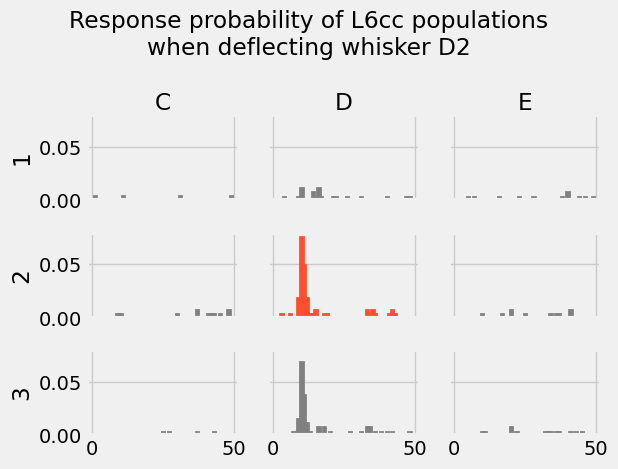

In [25]:
ct = "L6cc"
whisker = "D2"
fig, axs = activity_gridplot(ct, deflected_whisker=whisker)
I.plt.show()

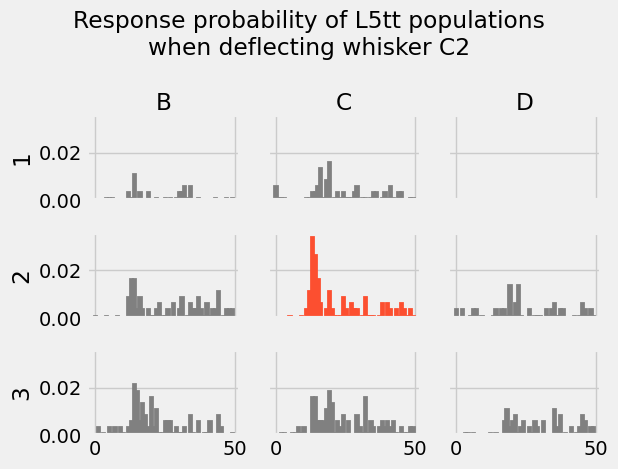

In [26]:
ct = "L5tt"
whisker = "C2"
fig, axs = activity_gridplot(ct, deflected_whisker=whisker)
I.plt.show()

## Recap

[Tutorial 2.1](./2.1%20Anatomical%20embedding.ipynb) covered how to embed a neuron model into a network reconstruction, taking into account the relevant morphological, cellular and network properties. This tutorial covered how to generate synaptic activity. We are now ready to combine our biophysically detailed neuron model with this network model: see [Tutorial 3.1](../3.%20multiscale%20models/3.1%20Multiscale%20modeling.ipynb).